In [1]:
import sys, os
sys.path.insert(0, '/home/okonias/projects/td-mpc_o2')
sys.path.insert(0, '/home/okonias/projects/td-mpc_o2/tdmpc/src')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
import torch
import numpy as np
import time
from pathlib import Path
from omegaconf import OmegaConf
from cfg import parse_cfg
from env import make_env
from algorithm.helper import Episode, ReplayBuffer, linear_schedule
from o2.tdmpc_o2 import TDMPC_O2
from o2.training_utils import set_seed, update_tdmpc, update_decoder
from o2.eval_utils import evaluate_agent

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
O2_DEFAULTS = {
    'latent_action_dim': 128, 'decoder_init': False, 'use_latent_state': True,
    'dcem_batch_size': 64, 'decoder_updates': 100, 'told_updates': 500,
    'decoder_start_steps': 5000, 'exp_name': 'o2_ddpg',
    'latent_num_samples': 32, 'latent_num_elites': 8, 'dcem_sampling_n': None,
}

CFG_PATH = Path('/home/okonias/projects/td-mpc_o2/tdmpc/cfgs')
sys.argv = ['train', 'task=fish-swim', 'seed=10']
cfg = parse_cfg(CFG_PATH)
cfg = OmegaConf.merge(OmegaConf.create(O2_DEFAULTS), cfg)

ar = cfg.action_repeat  # already set from task yaml
cfg = OmegaConf.merge(cfg, OmegaConf.create({
    'iterations' : 5,
    'told_updates' : 500,
    'decoder_updates': 100,

    # evaluation
    'eval_episodes': 0,
    'video_mode':    'none',

    # training — divided by action_repeat so wall-clock steps are consistent
    'train_steps':  60000 // ar,
    'seed_steps':   4000 // ar,   #CHANGE THIS
    'episode_length':   1000 // ar,

    # schedules — end step also divided by action_repeat
    'horizon_schedule':  f'linear(1, ${{horizon}}, {25000 // ar})',     #AND THIs
    'std_schedule':      f'linear(0.5, ${{min_std}}, {25000 // ar})',

    'decoder_start_steps':  0 // ar,
    'dcem_batch_size':   128,         #CHANGE THIS
    'use_is_weights'    : True,
    'decoder_uniform_sampling': False,
    'use_latent_state': True,
    'decoder_init':   None,

     #'load_model': "models/cheetah-run20k/model.pt",
     #'load_buffer':  "models/cheetah-run20k/replay_buffer.pth",

    'momentum'          : 0.1,

    'lml_temperature'   : 20,
    'dec_grad_clip_norm': 10,

    'latent_action_dim': 128,
    'lambda_gae':        0.5,
    'diversity_coeff':   1,
    'log_det_target' :   -4,
    'use_raw_obs': False,

    'latent_num_samples': 32,
    'latent_num_elites': 8,
    
    'gmm_num_samples': 256,
    'gmm_K': 2,
    'gmm_n_iters': 5,
    'gmm_init': 'kmeans++', # 'kmeans++' (default), 'forgy', or 'no_init'
    'gmm_kmeans_iters': 1,
}))
# Override anything here:
# cfg.lr = 3e-4
# cfg.decoder_start_steps = 2000

print(OmegaConf.to_yaml(cfg))

latent_action_dim: 128
decoder_init: null
use_latent_state: true
dcem_batch_size: 128
decoder_updates: 100
told_updates: 500
decoder_start_steps: 0
exp_name: default
latent_num_samples: 32
latent_num_elites: 8
dcem_sampling_n: null
task: fish-swim
modality: state
action_repeat: 4
discount: 0.99
episode_length: 250
train_steps: 15000
iterations: 5
num_samples: 512
num_elites: 64
mixture_coef: 0.05
min_std: 0.05
temperature: 0.5
momentum: 0.1
batch_size: 512
max_buffer_size: 1000000
horizon: 5
reward_coef: 0.5
value_coef: 0.1
consistency_coef: 2
rho: 0.5
kappa: 0.1
lr: 0.001
std_schedule: linear(0.5, ${min_std}, 6250)
horizon_schedule: linear(1, ${horizon}, 6250)
per_alpha: 0.6
per_beta: 0.4
grad_clip_norm: 10
seed_steps: 1000
update_freq: 2
tau: 0.01
enc_dim: 256
mlp_dim: 512
latent_dim: 50
use_wandb: false
wandb_project: none
wandb_entity: none
seed: 10
eval_freq: 20000
eval_episodes: 0
save_video: false
save_model: false
task_title: Fish Swim
device: cuda
video_mode: none
use_is_weigh

In [5]:
set_seed(cfg.seed)
env    = make_env(cfg)
agent  = TDMPC_O2(cfg)
buffer = ReplayBuffer(cfg)
step, episode_idx = 0, 0
start_time = time.time()
print('Ready')

Ready


In [5]:
if cfg.get('load_model', None):
    d = torch.load(cfg.load_model)
    state_dict = d['model'] if 'model' in d else d
    for k in [k for k in state_dict if k.startswith('_action_decoder') or k.startswith('_V')]:
        del state_dict[k]
    agent.model.load_state_dict(state_dict, strict=False)
    if 'model_target' in d:
        target_dict = d['model_target']
        for k in [k for k in target_dict if k.startswith('_action_decoder') or k.startswith('_V')]:
            del target_dict[k]
        agent.model_target.load_state_dict(target_dict, strict=False)
        print("Target loaded")
    else:
        agent.model_target.load_state_dict(agent.model.state_dict(), strict=False)
        print("Target copied")
    print(f'Loaded model from {cfg.load_model}')
if cfg.get('load_buffer', None):
    buffer.__dict__.update(torch.load(cfg.load_buffer, weights_only=False))
    print(f'Loaded buffer from {cfg.load_buffer}')


Target loaded
Loaded model from models/tmp8nrkj87x.pt


In [14]:

# --- Decoder pretraining ---
agent.cfg.decoder_updates = 300
dec_metrics = update_decoder(agent, buffer, cfg, step=0)
agent.cfg.decoder_updates =  100

for k, v in dec_metrics.items():
    if k != 'grad_tracker':
        print(f'  {k:<20}: {v:>8.4f}')

KeyboardInterrupt: 

In [6]:
num_episodes = 30
W = 38

print("Number of episodes:", num_episodes)
for _ in range(num_episodes):
    phase = 'o2' if step >= cfg.decoder_start_steps else 'tdmpc'
    obs = env.reset()
    episode = Episode(cfg, obs)
    t_ep = time.time()

    u_mean_norms, u_std_means = [], []
    while not episode.done:
        if step < cfg.seed_steps:
            action = torch.tensor(env.action_space.sample(), dtype=torch.float32, device=agent.device)
        elif phase == 'tdmpc':
            action = agent.plan(obs, step=step, t0=episode.first)
        else:
            action, u_mean, u_std, *_ = agent.CEM_in_latent(obs, step=step, sample_final_action=True)
            u_mean_norms.append(u_mean.norm().item())
            u_std_means.append(u_std.mean().item())

        obs, reward, done, _ = env.step(action.cpu().numpy())
        episode += (obs, action, reward, done)
    buffer += episode
    ep_time = time.time() - t_ep

    step += cfg.episode_length
    episode_idx += 1
    env_step = int(step * cfg.action_repeat)
    print('─' * W)
    print(f'  Episode {episode_idx}   step {env_step:,}   [{phase}]')
    print('─' * W)
    print(f'  {"Reward":<16}: {episode.cumulative_reward:>8.1f}')
    print(f'  {"Horizon":<16}: {int(linear_schedule(cfg.horizon_schedule, step)):>8}')
    print(f'  {"Std":<16}: {linear_schedule(cfg.std_schedule, step):>8.3f}')
    print(f'  {"Ep time":<16}: {ep_time:>7.1f}s')
    if(step > cfg.decoder_start_steps and step> cfg.seed_steps):
        print(f'  {"CEM u_mean norm":<16}: {sum(u_mean_norms)/len(u_mean_norms):>8.4f}')
        print(f'  {"CEM u_std mean":<16}: {sum(u_std_means)/len(u_std_means):>8.4f}')
    
    train_metrics, update_time = {}, 0.0

    if step >= cfg.seed_steps:
        t = time.time()
        train_metrics = update_tdmpc(agent, buffer, step)
        update_time = time.time() - t

    dec_metrics = {}
    decoder_time = 0.0
    if (phase == 'o2' and step >= cfg.seed_steps):
        t = time.time()
        dec_metrics = update_decoder(agent, buffer, cfg, step)
        decoder_time = time.time() - t
        for iteration, norm in sorted(dec_metrics['grad_tracker']):
            print(f'  DCEM iter {iteration} grad norm: {norm:.6f}')



    print(f'  {"Update time":<16}: {update_time:>7.1f}s')
    if dec_metrics:
        print(f'  {"Decoder time":<16}: {decoder_time:>7.1f}s')
        for k, v in dec_metrics.items():
            if k != 'grad_tracker':
                print(f'  {k:<20}: {v:>8.4f}')
        eval_metrics = evaluate_agent(
            env,
            agent,
            cfg,
            step=step,
            n_episodes=1,
            use_latent=True,
            save_dir='eval_videos/temp7',
            video_mode='first',   # or 'first'
            sample_final_action=True,
        )
    print(f'  {"Total time":<16}: {time.time() - start_time:>7.0f}s')

    if train_metrics:
        for k, v in train_metrics.items():
            print(f'  {k:<20}: {v:>8.4f}')



Number of episodes: 30
──────────────────────────────────────
  Episode 1   step 1,000   [o2]
──────────────────────────────────────
  Reward          :    323.9
  Horizon         :        1
  Std             :    0.482
  Ep time         :     0.4s
  Update time     :     0.0s
  Total time      :       2s
──────────────────────────────────────
  Episode 2   step 2,000   [o2]
──────────────────────────────────────
  Reward          :     40.5
  Horizon         :        1
  Std             :    0.464
  Ep time         :     0.4s
  Update time     :     0.0s
  Total time      :       2s
──────────────────────────────────────
  Episode 3   step 3,000   [o2]
──────────────────────────────────────
  Reward          :      8.0
  Horizon         :        1
  Std             :    0.446
  Ep time         :     0.4s
  Update time     :     0.0s
  Total time      :       3s
──────────────────────────────────────
  Episode 4   step 4,000   [o2]
──────────────────────────────────────
  Reward       

KeyboardInterrupt: 

In [ ]:
B = 256
obs_batch = buffer.sample()[0][:B]
z_batch = obs_batch if cfg.use_raw_obs else agent.model_target.h(obs_batch).detach()  # real, diverse states

u0    = torch.zeros(1, cfg.latent_action_dim, device=agent.device)
delta = torch.randn(1, cfg.latent_action_dim, device=agent.device)
delta = delta / delta.norm()
eps   = 0.05

with torch.no_grad():
    seq0 = agent.model.decode_sequence(u0.repeat(B, 1), z_batch)
    seq1 = agent.model.decode_sequence((u0 + eps * delta).repeat(B, 1), z_batch)

response = (seq1 - seq0).permute(1, 0, 2).reshape(B, -1).norm(dim=-1) / eps  # [B]
print(f"response mean={response.mean():.4f}  std={response.std():.4f}  "
      f"cv={response.std()/response.mean():.3f}  min={response.min():.4f}  max={response.max():.4f}")


response mean=0.1684  std=0.0489  cv=0.290  min=0.0786  max=0.3318


In [ ]:
def decoder_jacobian(agent, u0, z0):
    def f(u):
        seq = agent.model.decode_sequence(u.unsqueeze(0), z0.unsqueeze(0))
        return seq.reshape(-1)
    return torch.autograd.functional.jacobian(f, u0)  # [horizon*action_dim, latent_action_dim]

u0 = torch.zeros(cfg.latent_action_dim, device=agent.device)
n_states = 8
z_samples = z_batch[:n_states]

jacobians = [decoder_jacobian(agent, u0, z_samples[i]) for i in range(n_states)]
svs = [torch.linalg.svdvals(J) for J in jacobians]  # singular values, one vector per state

for i, s in enumerate(svs):
    print(f"z[{i}]: top-5 singular values = {s[:5].cpu().numpy().round(3)}")


z[0]: top-5 singular values = [1.602 1.376 0.696 0.656 0.519]
z[1]: top-5 singular values = [1.971 1.597 0.921 0.747 0.696]
z[2]: top-5 singular values = [1.25  0.79  0.717 0.533 0.458]
z[3]: top-5 singular values = [1.653 1.26  0.846 0.553 0.482]
z[4]: top-5 singular values = [1.38  0.924 0.584 0.467 0.436]
z[5]: top-5 singular values = [1.632 1.164 0.838 0.665 0.62 ]
z[6]: top-5 singular values = [1.688 1.098 0.926 0.787 0.432]
z[7]: top-5 singular values = [1.709 1.598 0.829 0.741 0.579]


In [ ]:
import torch.nn.utils as utils
def update_decoder_DDPG(self, obs, u_mean, horizon, weights=None, log_det_loss=None, u_std=None):
    """
    DDPG-style decoder update using a GAE-weighted sum of n-step TD targets.

    V_λ = Σ_h w_h * V_h, where
        w_h = (1 - λ) * λ^(h-1)  for h < gae_horizons
        w_H = λ^(H-1)             (absorbs remaining weight; all weights sum to 1)

    Config: lambda_gae (default 0.5), gae_horizons (default 5).
    Saturation is monitored but not penalised.

    Args:
        obs:     [B, obs_dim] observation batch from the replay buffer.
        u_mean:  [B, latent_action_dim] differentiable latent action mean
                 obtained from DCEM().
        horizon: int planning horizon (used as GAE rollout length).
        weights: optional [B] importance-sampling weights.

    Returns:
        dict with keys: decoder_loss, decoder_grad_norm, value_mean,
                        saturation, z_norm, u_norm, hidden_norm
    """
    self.action_dec_optim.zero_grad()

    use_raw_obs = getattr(self.cfg, 'use_raw_obs', False)
    z                 = self.model.h(obs).detach()
    cond_dec          = obs if use_raw_obs else self.model_target.h(obs).detach()
    z_norm            = z.norm(dim=-1).mean().item()

    # Reparameterized sample from the DCEM distribution: gradients on the
    # decoder loss flow back through both u_mean and u_std, not just u_mean.
    if u_std is not None:
        u = u_mean + u_std * torch.randn_like(u_mean)
    else:
        u = u_mean
    u_norm            = u.norm(dim=-1).mean().item()
    sequence, pretanh = self.model.decode_sequence(u, cond_dec, return_pretanh=True)
    saturation        = pretanh.abs().mean().item()

    value = self.estimate_value_GAE(z, sequence, horizon).nan_to_num(0).squeeze(-1)
    lam   = getattr(self.cfg, 'lambda_gae', 0.5)

    if hasattr(self, 'log_alpha_diversity'):
        alpha = self.log_alpha_diversity.exp().item()
    else:
        alpha = getattr(self.cfg, 'diversity_coeff', 0.0)

    diversity_cost = alpha * log_det_loss if (log_det_loss is not None and alpha > 0) else 0.0
    value_cost     = (-value).mean()
    per_sample_cost = -value
    if weights is not None:
        cost = (per_sample_cost * weights).mean()
    else:
        cost = per_sample_cost.mean()
    cost = cost + (diversity_cost if hasattr(diversity_cost, 'backward') else 0.0)

    cost.backward()
    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), max_norm=dec_grad_clip)
    self.action_dec_optim.step()

    if log_det_loss is not None and hasattr(self, 'log_alpha_diversity'):
        alpha_loss = -(self.log_alpha_diversity * (log_det_loss.detach() + self.log_det_target))
        self.alpha_diversity_optim.zero_grad()
        alpha_loss.backward()
        self.alpha_diversity_optim.step()

    diversity_cost_val = diversity_cost.item() if hasattr(diversity_cost, 'item') else float(diversity_cost)
    return {
        'decoder_loss':      cost.item(),
        'value_cost':        value_cost.item(),
        'diversity_cost':    diversity_cost_val,
        'diversity_alpha':   alpha,
        'decoder_grad_norm': grad_norm.item(),
        'value_mean':        value.mean().item(),
        'saturation':        saturation,
        'z_norm':            z_norm,
        'u_norm':            u_norm,
        'hidden_norm':       self.model._action_decoder._hidden_norm,
        'lambda_gae':        lam,
    }
setattr(TDMPC_O2, "update_decoder_DDPG", update_decoder_DDPG)

Saturation fraction per dim: [0.023 0.008 0.019 0.037 0.068 0.015]
Variance per dim:           [0.228 0.045 0.112 0.299 0.159 0.229]
Uniform [-1,1] variance:    0.333


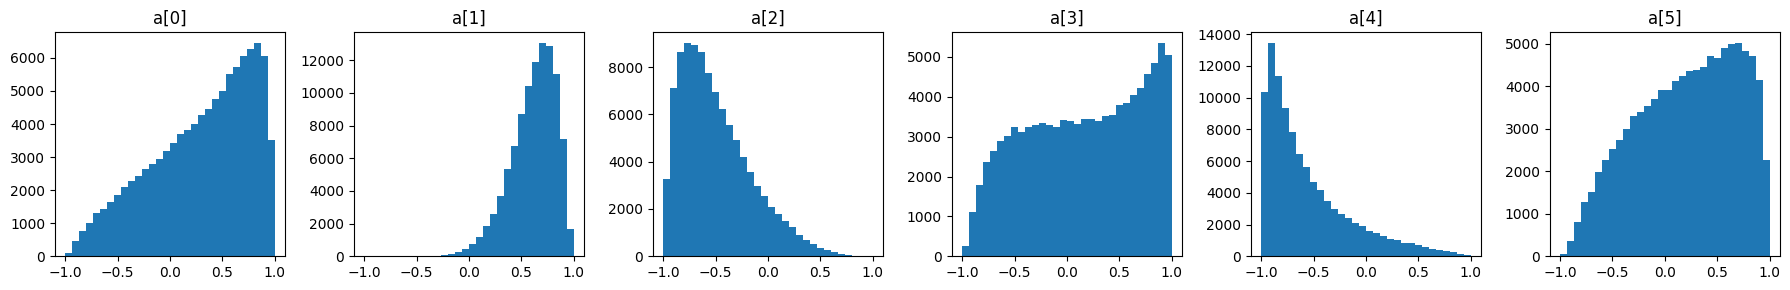

NameError: name 'u_mean' is not defined

In [8]:
n = 100000
obs_batch = buffer.sample()[0][:1].repeat(n, 1)
u = torch.randn(n, cfg.latent_action_dim, device=agent.device)
cond = obs_batch if cfg.use_raw_obs else agent.model_target.h(obs_batch).detach()

with torch.no_grad():
    seq, pretanh = agent.model.decode_sequence(u, cond, return_pretanh=True)
    actions = seq[0]      # [n, action_dim] — first horizon step
    pt      = pretanh[0]  # [n, action_dim] — pre-tanh values

# Saturation fraction — fraction of outputs near the bounds
sat_fraction = (actions.abs() > 0.95).float().mean(dim=0)  # per action dim
print("Saturation fraction per dim:", sat_fraction.cpu().numpy().round(3))

# Bimodality: compare variance to what a uniform on [-1,1] would give (=1/3)
# If variance >> 1/3, mass is piling at the extremes
var_per_dim = actions.var(dim=0)
print("Variance per dim:          ", var_per_dim.cpu().numpy().round(3))
print("Uniform [-1,1] variance:    0.333")

# Histogram per action dim
import matplotlib.pyplot as plt
A = actions.shape[1]
fig, axes = plt.subplots(1, A, figsize=(3*A, 3))
for i, ax in enumerate(axes):
    ax.hist(actions[:, i].cpu().numpy(), bins=30, range=(-1, 1))
    ax.set_title(f'a[{i}]')
plt.tight_layout()
plt.show()
import gc
import torch
del seq, pretanh, actions, u_mean, u_std
gc.collect()
torch.cuda.empty_cache()


In [11]:

import gc
import torch

gc.collect()
torch.cuda.empty_cache()
B = 1000
obs_batch = buffer.sample()[0][:B]

_, u_mean, u_std, *_ = agent.DCEM(obs_batch, step=step)
u_mean = u_mean.detach()
u_std  = u_std.detach()

u_samples = u_mean + u_std * torch.randn_like(u_mean)  # [B, latent_dim]

cond = obs_batch if cfg.use_raw_obs else agent.model_target.h(obs_batch).detach()
with torch.no_grad():
    seq, pretanh = agent.model.decode_sequence(u_samples, cond, return_pretanh=True)
    actions = seq[0].cpu()  # [B, action_dim]

A = actions.shape[1]
print("Saturation fraction per dim:", (actions.abs() > 0.95).float().mean(dim=0).numpy().round(3))
print("Variance per dim:           ", actions.var(dim=0).numpy().round(3))
print("Mean per dim:               ", actions.mean(dim=0).numpy().round(3))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, A, figsize=(3*A, 3))
for i, ax in enumerate(axes if A > 1 else [axes]):
    ax.hist(actions[:, i].numpy(), bins=20, range=(-1, 1))
    ax.axvline(0, color='r', linestyle='--', alpha=0.5)
    ax.set_title(f'a[{i}]')
    ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 11.76 GiB of which 32.19 MiB is free. Including non-PyTorch memory, this process has 11.71 GiB memory in use. Of the allocated memory 11.52 GiB is allocated by PyTorch, and 19.14 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import gc
import torch


gc.collect()
torch.cuda.empty_cache()

In [15]:
agent.cfg.num_samples = 512
agent.cfg.num_elites  = 64

step= 30000
eval_metrics = evaluate_agent(
    env,
    agent,
    cfg,
    step=step,
    n_episodes=5,
    use_latent=True,
    save_dir='eval_videos',
    video_mode='best_worst',   # or 'first'
    sample_final_action=True,
)


Episode 1/5: Reward = 377.468
Episode 2/5: Reward = 601.812
Episode 3/5: Reward = 611.771
Episode 4/5: Reward = 650.090
Episode 5/5: Reward = 566.194
🏆 Saved best episode video: eval_videos/videos/eval_step30000_best_ep004.mp4
💀 Saved worst episode video: eval_videos/videos/eval_step30000_worst_ep001.mp4

Evaluation Summary — Step 30000
-------------------------
Mean Reward: 561.467
Std Reward:  95.802


In [ ]:
agent.cfg.num_samples = 512
agent.cfg.num_elites  = 64

eval_metrics = evaluate_agent(
    env,
    agent,
    cfg,
    step=step,
    n_episodes=5,
    use_latent=False,
    save_dir='eval_videos',
    video_mode='none',   # or 'first'
    sample_final_action=False,
)

RuntimeError: The expanded size of the tensor (3) must match the existing size (4) at non-singleton dimension 0.  Target sizes: [3, 6].  Tensor sizes: [4, 6]

In [ ]:
import torch
del agent, buffer  # or whatever large objects
torch.cuda.empty_cache()

In [ ]:
import torch.nn.utils as utils
import pandas as pd
#PAIRWISE DISTANCES LOSS, DIAGONAL ELEMENTS INCLUDED
def update_decoder_DDPG(self, obs, u_mean, horizon, weights=None, log_det_loss=None, u_std=None):
    self.action_dec_optim.zero_grad()

    k     = getattr(self.cfg, 'diversity_k_samples', 3)
    #sigma = getattr(self.cfg, 'diversity_sigma', 0.1)
    B     = u_mean.shape[0]

    z      = self.model.h(obs).detach()
    z_norm = z.norm(dim=-1).mean().item()
    u_norm = u_mean.norm(dim=-1).mean().item()

    min_std   = self.std
    noise     = torch.randn(k, B, u_mean.shape[-1], device=z.device)
    u_samples = u_mean.unsqueeze(0) + u_std.clamp(min=min_std).unsqueeze(0) * noise


    u_flat    = u_samples.permute(1, 0, 2).reshape(B * k, -1)
    z_rep     = z.repeat_interleave(k, dim=0)

    seqs, pretanh = self.model.decode_sequence(u_flat, z_rep, return_pretanh=True)
    saturation    = pretanh.abs().mean().item()

    #values = self.estimate_value_with_grad(z_rep, seqs, horizon).nan_to_num(0).squeeze(-1)

    values = self.estimate_value_GAE(z_rep, seqs, horizon).nan_to_num(0).squeeze(-1)

    seqs_bk = seqs[:horizon].reshape(horizon, B, k, -1).permute(1, 2, 0, 3).flatten(2)

    values_bk = values.reshape(B, k)

    v         = (values_bk - values_bk.min(dim=1, keepdim=True).values.detach()).clamp(min=1e-6)
    #v         = values_bk.clamp(min=1e-6)
    #v = values_bk.clamp(min=1e-6)
    dists     = torch.cdist(seqs_bk, seqs_bk)
    sigma     = dists.detach().mean().clamp(min=1e-6)


    scaled_dists = 1 + dists/sigma    # linear growth, starts at 1 like exp
    #scaled_dists = torch.exp((dists/sigma).clamp(max=3))

    #v_weights    = v.unsqueeze(2) * v.unsqueeze(1)
    v_weights = v.sqrt().unsqueeze(2) * v.sqrt().unsqueeze(1)
    #v_weights = v.sqrt().unsqueeze(2) * v.sqrt().unsqueeze(1)
    mask      = torch.triu(torch.ones(k, k, device=z.device, dtype=torch.bool), diagonal=0)
    cost      = -(v_weights * scaled_dists)[: , mask].mean()
    cost.backward()


    k = v.shape[1]

    cost_matrix         = (v_weights * scaled_dists).detach().mean(dim=0).cpu().numpy()
    dist_matrix         = dists.detach().mean(dim=0).cpu().numpy()
    dist_score_matrix = scaled_dists.detach().mean(dim=0).cpu().numpy()
    val_matrix          = v_weights.detach().mean(dim=0).cpu().numpy()

    df_cost       = pd.DataFrame(cost_matrix.round(3), index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])
    df_dist       = pd.DataFrame(dist_matrix.round(3), index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])
    df_dist_score = pd.DataFrame(dist_score_matrix.round(3), index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])
    df_val        = pd.DataFrame(val_matrix.round(3),  index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])

    print("=== distances ===");       print(df_dist.to_string())
    print("=== exp_dists ===");       print(df_dist_score.to_string())
    print("=== value weights ===");   print(df_val.to_string())
    print("=== cost matrix ===");     print(df_cost.to_string())

    seqs_bk_unflat = seqs[:horizon].reshape(horizon, B, k, -1).permute(1, 2, 0, 3)

    per_step_dists = []
    for t in range(horizon):
        d_t = torch.cdist(seqs_bk_unflat[:, :, t, :], seqs_bk_unflat[:, :, t, :])  # [B, k, k]
        mask = torch.triu(torch.ones(k, k, dtype=torch.bool, device=d_t.device), diagonal=1)
        per_step_dists.append(d_t[:, mask].mean().item())

    for t, d in enumerate(per_step_dists):
        print(f"  t={t}: mean_dist = {d:.4f}")
    print(f"  total (flattened): {dists.detach()[:, mask].mean().item():.4f}")

    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), dec_grad_clip)
    self.action_dec_optim.step()

    return {
        'decoder_loss':      cost.item(),
        'decoder_grad_norm': grad_norm.item(),
        'value_mean':        values_bk.mean().item(),
        'saturation':        saturation,
        'z_norm':            z_norm,
        'u_norm':            u_norm,
        'hidden_norm':       self.model._action_decoder._hidden_norm,
    }
setattr(TDMPC_O2, "update_decoder_DDPG", update_decoder_DDPG)

In [ ]:
import torch.nn.utils as utils
import pandas as pd
#DPP LOSS
def update_decoder_DDPG(self, obs, u_mean, horizon, weights=None, log_det_loss=None):
    self.action_dec_optim.zero_grad()

    k     = getattr(self.cfg, 'diversity_k_samples', 8)
    sigma_noise = getattr(self.cfg, 'diversity_sigma', 0.05)
    B     = u_mean.shape[0]

    z      = self.model.h(obs).detach()
    z_norm = z.norm(dim=-1).mean().item()
    u_norm = u_mean.norm(dim=-1).mean().item()

    noise     = torch.randn(k, B, u_mean.shape[-1], device=z.device)
    u_samples = u_mean.unsqueeze(0) + sigma_noise * noise
    u_flat    = u_samples.permute(1, 0, 2).reshape(B * k, -1)
    z_rep     = z.repeat_interleave(k, dim=0)

    seqs, pretanh = self.model.decode_sequence(u_flat, z_rep, return_pretanh=True)
    saturation    = pretanh.abs().mean().item()

    values = self.estimate_value_with_grad(z_rep, seqs, horizon).nan_to_num(0).squeeze(-1)

    seqs_bk   = seqs.reshape(horizon, B, k, -1).permute(1, 2, 0, 3).flatten(2)
    values_bk = values.reshape(B, k)

    v     = (values_bk - values_bk.min(dim=1, keepdim=True).values.detach()).clamp(min=1e-6)
    dists = torch.cdist(seqs_bk, seqs_bk)
    sigma = getattr(self.cfg, 'dpp_sigma', 1.0)
    K     = torch.exp(-dists**2 / (2 * sigma**2))
    L     = v.unsqueeze(2) * K * v.unsqueeze(1)
    L     = L + 1e-4 * torch.eye(k, device=z.device).unsqueeze(0)
    sign, logdet = torch.linalg.slogdet(L)
    cost  = -(sign * logdet).mean()

    cost.backward()

    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), dec_grad_clip)
    self.action_dec_optim.step()

    with torch.no_grad():
        L_print = L.detach().mean(dim=0)
        df = pd.DataFrame(L_print.cpu().numpy().round(3),
                          index=[f"s{i}" for i in range(k)],
                          columns=[f"s{j}" for j in range(k)])
        print(df.to_string())

    return {
        'decoder_loss':      cost.item(),
        'decoder_grad_norm': grad_norm.item(),
        'value_mean':        values_bk.mean().item(),
        'saturation':        saturation,
        'z_norm':            z_norm,
        'u_norm':            u_norm,
        'hidden_norm':       self.model._action_decoder._hidden_norm,
    }
setattr(TDMPC_O2, "update_decoder_DDPG", update_decoder_DDPG)

In [ ]:
import torch.nn.utils as utils
def action_decoder_DDPG_update_v2(self, obs, u_mean, u_std, horizon, weights=None):
    """
    DDPG-style decoder update with entropy regularization and saturation penalty.

    Two saturation penalty options are available — select by uncommenting:
      Option 1 (inline jacobian penalty): fast, uses pretanh values directly.
      Option 2 (saturation_loss):         sampled, captures full distribution.

    Args:
        obs:     [B, obs_dim] observation batch from the replay buffer.
        u_mean:  [B, latent_action_dim] differentiable latent action mean
                 obtained from DCEMethod(update_mode=True).
        u_std:   [B, latent_action_dim] differentiable latent action std
                 obtained from DCEMethod(update_mode=True).
        horizon: int planning horizon.

    Returns:
        dict with keys: decoder_loss, decoder_grad_norm, saturation
    """
    # Are any TOLD params mistakenly receiving grads?
    for name, p in agent.model.named_parameters():
        if '_action_decoder' not in name and '_V' not in name:
            assert not p.requires_grad, f"TOLD param not frozen: {name}"

    self.action_dec_optim.zero_grad()

    z                 = self.model.h(obs).detach()
    sequence, pretanh = self.model.decode_sequence_pretanh(u_mean, z)
    value             = self.estimate_value_with_grad(z, sequence, horizon).nan_to_num(0).squeeze(-1)
    saturation        = pretanh.abs().mean().item()

    # --- Option 1: inline jacobian penalty [B], subtracted per batch element ---
    jacobian_penalty  = -torch.log(1 - sequence.pow(2) + 1e-6).sum(-1).mean(0)  # [B]
    per_sample_cost   = -(value - self.cfg.saturation_coeff * jacobian_penalty)
    if weights is not None:
        cost = (per_sample_cost * weights).mean()
    else:
        cost = per_sample_cost.mean()

    # --- Option 2: saturation_loss (sampled across distribution) [B] ---
    #saturation_coeff  = getattr(self.cfg, 'saturation_coeff', 0.0)
    #sat_loss          = self.saturation_loss(u_mean, u_std, z) if saturation_coeff > 0 else 0.0
    #per_sample_cost   = -(value - saturation_coeff * sat_loss)
    #if weights is not None:
    #    cost = (per_sample_cost * weights).mean()
    #else:
    #    cost = per_sample_cost.mean()
    cost.backward()

    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), max_norm=dec_grad_clip)
    self.action_dec_optim.step()

    return {'decoder_loss': cost.item(), 'decoder_grad_norm': grad_norm.item(), 'saturation': saturation}



setattr(TDMPC_O2, "action_decoder_DDPG_update_v2", action_decoder_DDPG_update_v2)


In [ ]:
from o2.eval_utils import evaluate_agent

metrics = evaluate_agent(
    env, agent, cfg,
    step=0,
    n_episodes=1,
    save_dir='./eval_output',
    video_mode='first',
)
for k, v in metrics.items():
    print(f'  {k:<20}: {v:>8.4f}')

Episode 1/1: Reward = 67.106
🎥 Saved first episode video: ./eval_output/videos/eval_step0_ep001.mp4

Evaluation Summary — Step 0
-------------------------
Mean Reward: 67.106
Std Reward:  0.000
  step                :   0.0000
  mean_reward         :  67.1056
  std_reward          :   0.0000
  mean_compute_duration:   0.0052
  episode_duration    :  22.3075


TypeError: unsupported format string passed to list.__format__

## Value calibration: predicted return vs actual outcome

Checks whether the model's CEM-predicted return matches what actually happens
in the env. Uses **closed-loop** `CEM_in_latent` (replans every step) rather
than the open-loop variant, since logging "every step" only makes sense when
every step's prediction is tied to the action actually taken — the open-loop
notebook only replans every `horizon` steps, so per-step predictions there
would either be stale (held over from the last replan) or decoupled from
control.

At every env step:
- **Predicted return**: `agent.estimate_value(z, decoded_sequence, horizon)`
  for the final latent action CEM converges to — the same value CEM used
  internally to select that action. This is a bootstrapped horizon-step
  lookahead (reward-over-horizon + target Q at the end), not a full-episode
  return.
- **Actual outcome**: discounted Monte Carlo return-to-go from that step to
  episode end, computed from real env rewards once the episode finishes.

This is a standalone eval rollout — it does not touch the training `step`
counter or `buffer`. Run it after some decoder training (`o2` phase); an
untrained decoder makes the comparison meaningless.


In [36]:
import algorithm.helper as h

def get_predicted_value(agent, obs, latent_action, step):
    """Predicted return for a single converged latent action, as CEM's
    estimate_value would score it (same z, same decode, same horizon)."""
    obs_t = obs if torch.is_tensor(obs) else \
            torch.tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0)
    horizon = int(min(agent.cfg.horizon, h.linear_schedule(agent.cfg.horizon_schedule, step)))
    use_raw_obs = getattr(agent.cfg, 'use_raw_obs', False)

    with torch.no_grad():
        z          = agent.model.h(obs_t)
        cond_final = obs_t if use_raw_obs else agent.model_target.h(obs_t)
        sequence   = agent.model.decode_sequence(latent_action, cond_final)
        value      = agent.estimate_value(z, sequence, horizon)

    return value.item()

print('get_predicted_value defined')


get_predicted_value defined


In [37]:
def get_predicted_value_tdmpc(agent, obs, step):
    """Predicted return for standard CEM's converged mean trajectory —
    read from agent._prev_mean right after agent.plan() is called."""
    obs_t = obs if torch.is_tensor(obs) else \
            torch.tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0)
    mean_traj = agent._prev_mean.unsqueeze(1)   # [horizon, 1, action_dim]
    horizon   = mean_traj.shape[0]

    with torch.no_grad():
        z     = agent.model.h(obs_t)
        value = agent.estimate_value(z, mean_traj, horizon)

    return value.item()

print('get_predicted_value_tdmpc defined')


get_predicted_value_tdmpc defined


In [38]:
agent.cfg.num_samples = 512
agent.cfg.num_elites  = 64

In [39]:
import os
import imageio

n_eval_episodes = 5
gamma = cfg.discount
eval_step = step  # current training step, used only for horizon/std schedules — not mutated

video_dir = os.path.join('eval_videos', 'videos')
os.makedirs(video_dir, exist_ok=True)

calibration_records = []  # rows: episode, t, predicted_latent, predicted_tdmpc, actual

for ep in range(n_eval_episodes):
    obs = env.reset()
    done = False
    t = 0
    predicted_values, predicted_values_tdmpc, rewards, frames = [], [], [], []

    while not done:
        action, u_mean, u_std, latent_action, log_probs = agent.CEM_in_latent(
            obs, step=eval_step, sample_final_action=False
        )
        predicted_values.append(get_predicted_value(agent, obs, latent_action, eval_step))

        agent.plan(obs, eval_mode=True, step=eval_step, t0=(t == 0))   # discard action, keep _prev_mean
        predicted_values_tdmpc.append(get_predicted_value_tdmpc(agent, obs, eval_step))

        obs, reward, done, _ = env.step(action.cpu().numpy())
        rewards.append(reward)
        t += 1

        try:
            frame = env.render(mode='rgb_array', height=480, width=640, camera_id=0)
        except TypeError:
            frame = env.render(mode='rgb_array')
        frames.append(frame)

    # backward discounted Monte Carlo return-to-go: R_t = r_t + gamma * R_{t+1}
    actual_returns = [0.0] * len(rewards)
    running = 0.0
    for i in reversed(range(len(rewards))):
        running = rewards[i] + gamma * running
        actual_returns[i] = running

    for t, (p, p_tdmpc, a) in enumerate(zip(predicted_values, predicted_values_tdmpc, actual_returns)):
        calibration_records.append({'episode': ep, 't': t, 'predicted_latent': p,
                                     'predicted_tdmpc': p_tdmpc, 'actual': a})

    video_path = os.path.join(video_dir, f'calibration_ep{ep+1:03d}.mp4')
    imageio.mimsave(video_path, frames, fps=30)

    print(f"Episode {ep+1}/{n_eval_episodes}: reward={sum(rewards):>8.1f}  "
          f"pred_latent[0]={predicted_values[0]:>8.2f}  pred_tdmpc[0]={predicted_values_tdmpc[0]:>8.2f}  "
          f"actual[0]={actual_returns[0]:>8.2f}  video={video_path}")



Episode 1/5: reward=   407.3  pred_latent[0]=   65.25  pred_tdmpc[0]=   62.93  actual[0]=   83.19  video=eval_videos/videos/calibration_ep001.mp4
Episode 2/5: reward=   120.3  pred_latent[0]=   85.14  pred_tdmpc[0]=   83.51  actual[0]=   44.45  video=eval_videos/videos/calibration_ep002.mp4
Episode 3/5: reward=   147.9  pred_latent[0]=  127.23  pred_tdmpc[0]=  125.18  actual[0]=   71.15  video=eval_videos/videos/calibration_ep003.mp4
Episode 4/5: reward=   523.9  pred_latent[0]=   91.34  pred_tdmpc[0]=   86.40  actual[0]=  128.36  video=eval_videos/videos/calibration_ep004.mp4
Episode 5/5: reward=    81.0  pred_latent[0]=   36.82  pred_tdmpc[0]=   36.30  actual[0]=   33.11  video=eval_videos/videos/calibration_ep005.mp4


predicted_latent   Correlation: 0.655   MSE: 4362.836
predicted_tdmpc    Correlation: 0.656   MSE: 4400.331
predicted_tdmpc - predicted_latent: mean gap = 0.467   correlation = 0.999


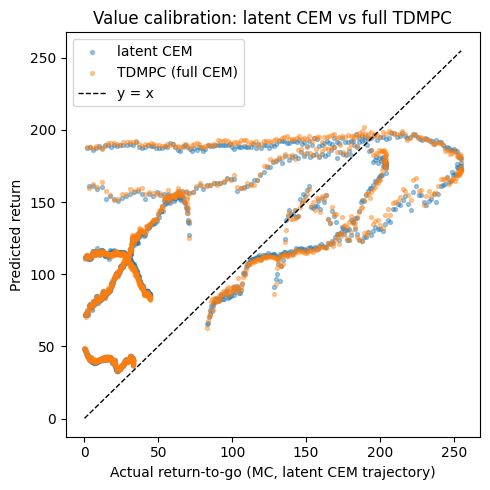

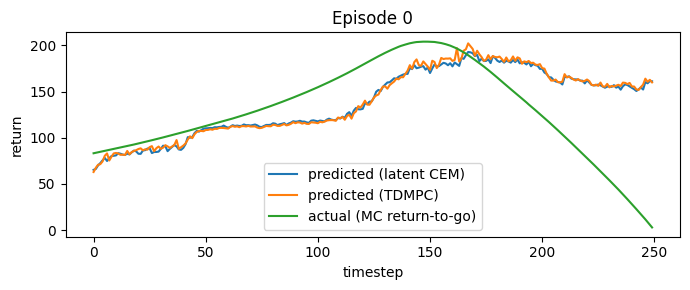

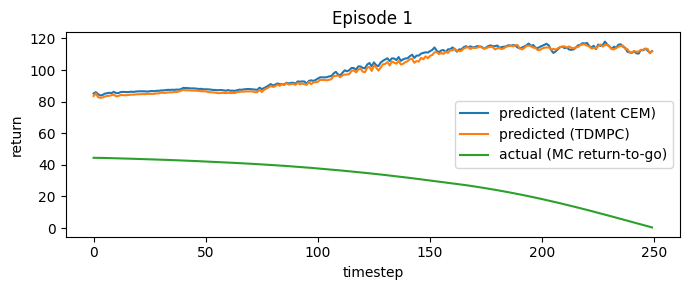

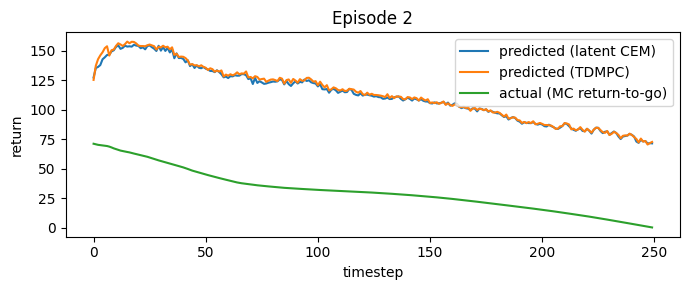

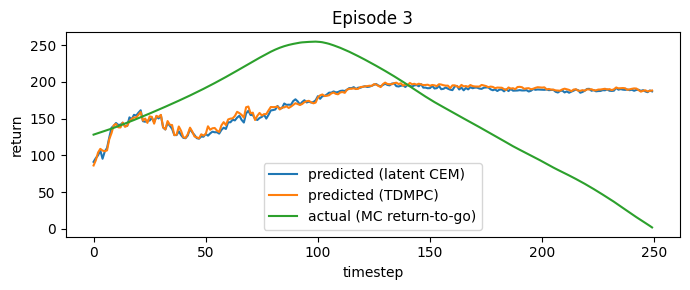

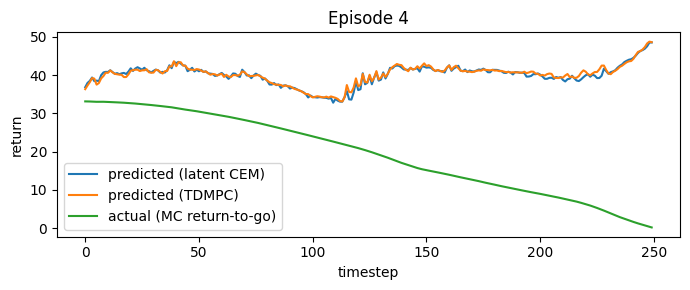

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(calibration_records)

for col in ['predicted_latent', 'predicted_tdmpc']:
    corr = df[col].corr(df['actual'])
    mse  = ((df[col] - df['actual']) ** 2).mean()
    print(f"{col:<18} Correlation: {corr:.3f}   MSE: {mse:.3f}")

gap_corr = df['predicted_latent'].corr(df['predicted_tdmpc'])
gap_mean = (df['predicted_tdmpc'] - df['predicted_latent']).mean()
print(f"predicted_tdmpc - predicted_latent: mean gap = {gap_mean:.3f}   correlation = {gap_corr:.3f}")

# Scatter: both predictions vs actual, all steps/episodes pooled
plt.figure(figsize=(5, 5))
plt.scatter(df['actual'], df['predicted_latent'], s=8, alpha=0.4, label='latent CEM')
plt.scatter(df['actual'], df['predicted_tdmpc'], s=8, alpha=0.4, label='TDMPC (full CEM)')
lo = min(df['actual'].min(), df['predicted_latent'].min(), df['predicted_tdmpc'].min())
hi = max(df['actual'].max(), df['predicted_latent'].max(), df['predicted_tdmpc'].max())
plt.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x')
plt.xlabel('Actual return-to-go (MC, latent CEM trajectory)')
plt.ylabel('Predicted return')
plt.title('Value calibration: latent CEM vs full TDMPC')
plt.legend()
plt.tight_layout()
plt.show()

# Per-episode: both predictions and actual over time
for ep in sorted(df['episode'].unique()):
    sub = df[df['episode'] == ep]
    plt.figure(figsize=(7, 3))
    plt.plot(sub['t'], sub['predicted_latent'], label='predicted (latent CEM)')
    plt.plot(sub['t'], sub['predicted_tdmpc'], label='predicted (TDMPC)')
    plt.plot(sub['t'], sub['actual'], label='actual (MC return-to-go)')
    plt.xlabel('timestep')
    plt.ylabel('return')
    plt.title(f'Episode {ep}')
    plt.legend()
    plt.tight_layout()
    plt.show()


## CEM warm-start diagnostic: trajectory shift-consistency

At each step t, decode the *converged mean* trajectory from `CEM_in_latent`
(not the noisy executed action). Compare the previous plan shifted by one
step (`traj_t[1:]`) against the freshly replanned trajectory with its last
step dropped (`traj_{t+1}[:-1]`) — both index the same absolute future
timesteps (t+1 ... t+H-1), so this is an apples-to-apples comparison of
"what we already planned for tomorrow" vs "what we now plan for tomorrow."


In [143]:
def get_planned_trajectory(agent, obs, step):
    """Run CEM_in_latent and decode the converged mean u_mean into the full
    horizon action sequence (not just the first action CEM_in_latent returns)."""
    obs_t = obs if torch.is_tensor(obs) else \
            torch.tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0)
    action, u_mean, u_std, latent_action, log_probs = agent.CEM_in_latent(
        obs, step=step, sample_final_action=False
    )
    use_raw_obs = getattr(agent.cfg, 'use_raw_obs', False)
    with torch.no_grad():
        cond = obs_t if use_raw_obs else agent.model_target.h(obs_t)
        sequence = agent.model.decode_sequence(u_mean.unsqueeze(0), cond)  # [horizon, 1, action_dim]
    return action, sequence.squeeze(1).cpu()  # [horizon, action_dim]

print('get_planned_trajectory defined')



get_planned_trajectory defined


In [144]:
import matplotlib.pyplot as plt

episode 1/5: 250 steps, horizon=5
episode 2/5: 250 steps, horizon=5
episode 3/5: 250 steps, horizon=5
episode 4/5: 250 steps, horizon=5
episode 5/5: 250 steps, horizon=5


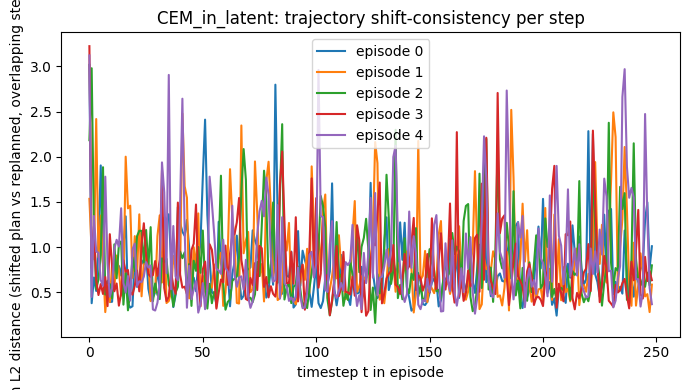

In [145]:
n_episodes = 5
eval_step = step  # fixed for the whole rollout, so horizon stays constant within an episode

step_diffs = []  # step_diffs[e] = one scalar per timestep t in episode e

for ep in range(n_episodes):
    obs = env.reset()
    done = False
    trajs = []
    while not done:
        action, traj = get_planned_trajectory(agent, obs, eval_step)
        trajs.append(traj)
        obs, reward, done, _ = env.step(action.cpu().numpy())

    diffs = []
    for t in range(len(trajs) - 1):
        shifted_prev = trajs[t][1:]       # planned at t, for absolute times t+1..t+H-1
        new_overlap  = trajs[t + 1][:-1]  # planned at t+1, for the same absolute times
        diffs.append((shifted_prev - new_overlap).norm(dim=-1).mean().item())
    step_diffs.append(diffs)
    print(f"episode {ep+1}/{n_episodes}: {len(trajs)} steps, horizon={trajs[0].shape[0]}")

plt.figure(figsize=(7, 4))
for e, diffs in enumerate(step_diffs):
    plt.plot(diffs, label=f'episode {e}')
plt.xlabel('timestep t in episode')
plt.ylabel('mean L2 distance (shifted plan vs replanned, overlapping steps only)')
plt.title('CEM_in_latent: trajectory shift-consistency per step')
plt.legend()
plt.tight_layout()
plt.show()


In [146]:
def get_planned_trajectory_tdmpc(agent, obs, step, t0):
    """Call agent.plan() (full CEM in action space) and read back the full
    horizon mean trajectory from _prev_mean (set as a side effect of plan())."""
    action = agent.plan(obs, eval_mode=True, step=step, t0=t0)
    return action, agent._prev_mean.clone().cpu()  # [horizon, action_dim]

print('get_planned_trajectory_tdmpc defined')


get_planned_trajectory_tdmpc defined


episode 1/5: 250 steps, horizon=5
episode 2/5: 250 steps, horizon=5
episode 3/5: 250 steps, horizon=5
episode 4/5: 250 steps, horizon=5
episode 5/5: 250 steps, horizon=5


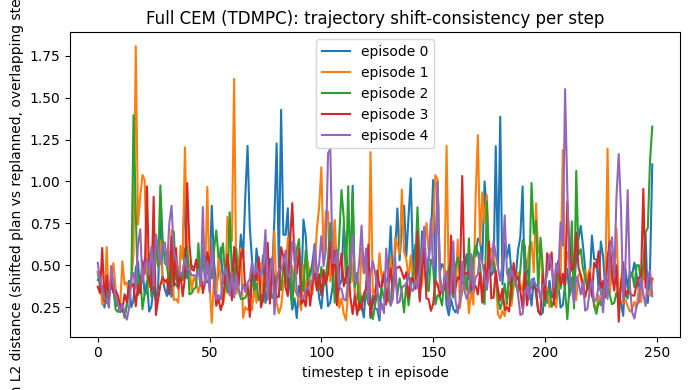

In [147]:
import matplotlib.pyplot as plt

n_episodes = 5
eval_step = step

step_diffs_tdmpc = []

for ep in range(n_episodes):
    obs = env.reset()
    done = False
    trajs = []
    t = 0
    while not done:
        action, traj = get_planned_trajectory_tdmpc(agent, obs, eval_step, t0=(t == 0))
        trajs.append(traj)
        obs, reward, done, _ = env.step(action.cpu().numpy())
        t += 1

    diffs = []
    for tt in range(len(trajs) - 1):
        shifted_prev = trajs[tt][1:]       # planned at tt, for absolute times tt+1..tt+H-1
        new_overlap  = trajs[tt + 1][:-1]  # planned at tt+1, for the same absolute times
        diffs.append((shifted_prev - new_overlap).norm(dim=-1).mean().item())
    step_diffs_tdmpc.append(diffs)
    print(f"episode {ep+1}/{n_episodes}: {len(trajs)} steps, horizon={trajs[0].shape[0]}")

plt.figure(figsize=(7, 4))
for e, diffs in enumerate(step_diffs_tdmpc):
    plt.plot(diffs, label=f'episode {e}')
plt.xlabel('timestep t in episode')
plt.ylabel('mean L2 distance (shifted plan vs replanned, overlapping steps only)')
plt.title('Full CEM (TDMPC): trajectory shift-consistency per step')
plt.legend()
plt.tight_layout()
plt.show()


## GMM fit visualization (B=1 decoder update)

Reproduces the fresh-sample GMM fit from `update_decoder_DDPG`
(o2/decoder_updates.py) for a single observation, so the fitted
mixture and the samples it was fit on can be plotted directly.
`fit_gmm_debug` mirrors `_fit_gmm`'s EM loop (o2/gmm_diversity.py)
but returns `mu, Sigma, pi` instead of collapsing them into scalar
metrics.

In [21]:
import torch

def fit_gmm_debug(seq, K=2, n_iters=5):
    """
    Same EM loop as o2/gmm_diversity.py::_fit_gmm, but returns the fitted
    (mu, Sigma, pi, responsibilities) for visualization instead of
    collapsing them into scalar metrics.

    seq: [H, B, N, A]
    """
    H, B, N, A = seq.shape
    dev = seq.device
    reg = 1e-4 * torch.eye(A, device=dev)
    TWO_PI = torch.tensor(2 * torch.pi, device=dev)

    with torch.no_grad():
        chunk = N // K
        mu = torch.stack(
            [seq[:, :, k * chunk:(k + 1) * chunk].mean(dim=2) for k in range(K)],
            dim=2,
        )
        global_mean = seq.mean(dim=2, keepdim=True)
        d0 = seq - global_mean
        Sigma = (d0.unsqueeze(-1) * d0.unsqueeze(-2)).mean(dim=2)
        Sigma = Sigma.unsqueeze(2).expand(H, B, K, A, A).clone()
        pi = seq.new_full((H, B, K), 1.0 / K)

        for _ in range(n_iters):
            diff      = seq.unsqueeze(3) - mu.unsqueeze(2)
            Sigma_reg = Sigma + reg
            L         = torch.linalg.cholesky(Sigma_reg)
            log_det   = 2 * L.diagonal(dim1=-2, dim2=-1).log().sum(-1)
            L_exp     = L.unsqueeze(2).expand(H, B, N, K, A, A)
            v         = torch.linalg.solve_triangular(L_exp, diff.unsqueeze(-1), upper=False)
            mahal     = (v * v).sum(dim=-2).squeeze(-1)
            log_lik   = -0.5 * (A * TWO_PI.log() + log_det.unsqueeze(2) + mahal)
            log_r     = log_lik + (pi + 1e-8).log().unsqueeze(2)
            r         = torch.softmax(log_r, dim=-1)

            N_k = r.sum(dim=2).clamp(min=1e-8)
            pi  = N_k / N
            mu  = (r.unsqueeze(-1) * seq.unsqueeze(3)).sum(dim=2) / N_k.unsqueeze(-1)

            diff  = seq.unsqueeze(3) - mu.unsqueeze(2)
            r_exp = r.unsqueeze(-1).unsqueeze(-1)
            Sigma = (r_exp * diff.unsqueeze(-1) * diff.unsqueeze(-2)).sum(dim=2) / N_k.unsqueeze(-1).unsqueeze(-1)

        Sigma_fixed = Sigma + reg

        # final responsibilities under the converged fit, for point coloring
        diff    = seq.unsqueeze(3) - mu.unsqueeze(2)
        L       = torch.linalg.cholesky(Sigma_fixed)
        log_det = 2 * L.diagonal(dim1=-2, dim2=-1).log().sum(-1)
        L_exp   = L.unsqueeze(2).expand(H, B, N, K, A, A)
        v       = torch.linalg.solve_triangular(L_exp, diff.unsqueeze(-1), upper=False)
        mahal   = (v * v).sum(dim=-2).squeeze(-1)
        log_lik = -0.5 * (A * TWO_PI.log() + log_det.unsqueeze(2) + mahal)
        log_r   = log_lik + (pi + 1e-8).log().unsqueeze(2)
        r       = torch.softmax(log_r, dim=-1)

    return mu, Sigma_fixed, pi, r

print('fit_gmm_debug defined')

fit_gmm_debug defined


In [36]:
# Single-observation (B=1) fresh-sample draw + GMM fit, mirroring the
# GMM-fitting block in update_decoder_DDPG (o2/decoder_updates.py:55-68).
gmm_num_samples = 512
gmm_K           = 2
gmm_n_iters     = 10

obs1        = buffer.sample()[0][:1]                       # single observation, B=1
use_raw_obs = getattr(cfg, 'use_raw_obs', False)
cond_dec    = obs1 if use_raw_obs else agent.model_target.h(obs1).detach()

_, u_mean, u_std, *_ = agent.DCEM(obs1, step=step)
u_mean, u_std = u_mean.detach(), u_std.detach()

noise      = torch.randn(1, gmm_num_samples, u_mean.shape[-1], device=u_mean.device)
gmm_u      = u_mean.unsqueeze(1) + u_std.unsqueeze(1) * noise
gmm_u_flat = gmm_u.reshape(gmm_num_samples, -1)
gmm_cond   = cond_dec.repeat(gmm_num_samples, 1)

with torch.no_grad():
    gmm_seq = agent.model.decode_sequence(gmm_u_flat, gmm_cond)   # [H, N, A]
    H, A    = gmm_seq.shape[0], gmm_seq.shape[-1]
    seq     = gmm_seq.view(H, 1, gmm_num_samples, A)[0:1]          # [1, 1, N, A] — first horizon step only

mu, Sigma, pi, r = fit_gmm_debug(seq, K=gmm_K, n_iters=gmm_n_iters)

actions     = seq[0, 0].cpu().numpy()        # [N, A] decoded action samples
mu_np       = mu[0, 0].cpu().numpy()         # [K, A]
Sigma_np    = Sigma[0, 0].cpu().numpy()      # [K, A, A]
resp_np     = r[0, 0].cpu().numpy()          # [N, K] soft assignment
hard_assign = resp_np.argmax(axis=1)

print(f'action_dim={A}  N={gmm_num_samples}  K={gmm_K}')
print('pi:', pi[0, 0].cpu().numpy().round(3))
print('mu:\n', mu_np.round(3))

action_dim=6  N=512  K=2
pi: [0.591 0.409]
mu:
 [[ 0.052  0.613  0.594 -0.075  0.236 -0.646]
 [ 0.145  0.509  0.525 -0.071  0.23  -0.481]]


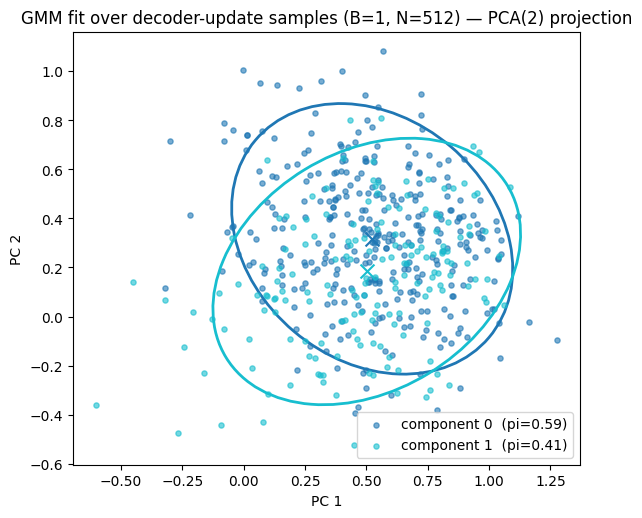

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def project_2d(actions, mu, Sigma):
    """Linear projection to 2D. Uses raw axes if A==2, else the top-2 PCA
    directions of the samples — a linear map keeps the GMM components
    Gaussian, so their covariance ellipses project exactly."""
    A = actions.shape[1]
    if A == 2:
        P = np.eye(2)
    else:
        centered = actions - actions.mean(axis=0, keepdims=True)
        _, _, Vt = np.linalg.svd(centered, full_matrices=False)
        P = Vt[:2]                                    # [2, A]
    actions_2d = actions @ P.T
    mu_2d      = mu @ P.T
    Sigma_2d   = np.einsum('ij,kjl,ml->kim', P, Sigma, P)
    return actions_2d, mu_2d, Sigma_2d

actions_2d, mu_2d, Sigma_2d = project_2d(actions, mu_np, Sigma_np)

fig, ax = plt.subplots(figsize=(6, 6))
colors = plt.cm.tab10(np.linspace(0, 1, mu_2d.shape[0]))

for k in range(mu_2d.shape[0]):
    mask = hard_assign == k
    ax.scatter(actions_2d[mask, 0], actions_2d[mask, 1], s=14, color=colors[k],
               alpha=0.6, label=f'component {k}  (pi={pi[0, 0, k].item():.2f})')

    vals, vecs = np.linalg.eigh(Sigma_2d[k])
    order      = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle      = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * 2 * np.sqrt(np.clip(vals, 0, None))   # 2-sigma ellipse
    ell = patches.Ellipse(mu_2d[k], width, height, angle=angle,
                           edgecolor=colors[k], facecolor='none', lw=2)
    ax.add_patch(ell)
    ax.scatter(*mu_2d[k], marker='x', s=100, color=colors[k])

title = f'GMM fit over decoder-update samples (B=1, N={actions.shape[0]})'
if A != 2:
    title += ' — PCA(2) projection'
ax.set_title(title)
ax.set_xlabel('dim 0' if A == 2 else 'PC 1')
ax.set_ylabel('dim 1' if A == 2 else 'PC 2')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()